# Temporal Dynamics Analysis: When Do Signals Emerge?

**Purpose**: Analyze WHEN within the PRE-decision window physiological signals diverge between INVEST vs KEEP decisions, and test whether time-aligned feature extraction improves classification.

**Key Questions**:
1. When does each modality's signal emerge relative to decision submission?
2. Which time bins show the strongest effects?
3. Can we improve accuracy by extracting features from optimal time windows?

**Method**:
1. Divide PRE-decision window into 500ms bins
2. Extract features within each bin
3. Compute effect sizes at each time point
4. Identify optimal windows per feature
5. Test time-aligned vs full-window classification

**Note on EEG Timing**:
- Pupil/Gaze: PRE-decision window is -2.0s to 0.0s (relative to submit)
- EEG: Only 1.25s of display period available (not directly time-locked to submit)
- EEG temporal bins represent display-period divisions, not exact decision-aligned time

In [1]:
import sys
sys.path.append('../..')

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats, signal
from sklearn.impute import SimpleImputer
from tqdm import tqdm
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from src.models.fusion import weighted_late_fusion
from src.features.eeg_features import FREQ_BANDS, CHANNEL_REGIONS, CHANNEL_NAMES

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Paths
PREPROCESSING_DIR = Path('../../data/results/preprocessing')
OUTPUT_DIR = Path('../../data/results/main/statistical_analyses/temporal_dynamics')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"{'='*70}")
print(f"TEMPORAL DYNAMICS ANALYSIS")
print(f"{'='*70}")
print(f"Analysis started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

TEMPORAL DYNAMICS ANALYSIS
Analysis started: 2026-03-30 16:42:12


## 1. Configuration

In [2]:
# Time window settings
WINDOW_START = -2.0  # seconds before submit
WINDOW_END = 0.0     # at submit
BIN_SIZE = 0.5       # 500ms bins

# Generate time bins
TIME_BINS = []
t = WINDOW_START
while t < WINDOW_END:
    TIME_BINS.append((t, min(t + BIN_SIZE, WINDOW_END)))
    t += BIN_SIZE

BIN_LABELS = [f"{tb[0]:.1f}s to {tb[1]:.1f}s" for tb in TIME_BINS]

print(f"PRE-decision window: {WINDOW_START}s to {WINDOW_END}s")
print(f"Bin size: {BIN_SIZE}s")
print(f"Time bins: {BIN_LABELS}")

BASELINE_METHOD = 't3_stable_pre_decision'
EEG_FS = 256  # EEG sampling rate

PRE-decision window: -2.0s to 0.0s
Bin size: 0.5s
Time bins: ['-2.0s to -1.5s', '-1.5s to -1.0s', '-1.0s to -0.5s', '-0.5s to 0.0s']


## 2. Load Data

In [3]:
# Load outcomes and pre-extracted features
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

merged_df = feature_data['merged_df']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']
physio_cols = feature_data['physio_cols']

outcome_lookup = dict(zip(merged_df['trial_id'], merged_df['outcome']))
print(f"Loaded outcomes for {len(outcome_lookup)} trials")

# Load raw JSON files for submit times (needed for gaze alignment)
RAW_DIR = Path('../../data/json')
raw_files = list(RAW_DIR.glob('*.json'))
print(f"Found {len(raw_files)} raw JSON files")

# Load continuous eye tracking data for gaze time-series
EYE_DIR = Path('../../data/eye')
eye_data_lookup = {}
for eye_file in EYE_DIR.glob('*.pkl'):
    subject_id = eye_file.stem
    with open(eye_file, 'rb') as f:
        eye_data_lookup[subject_id] = pickle.load(f)
print(f"Loaded eye tracking data for {len(eye_data_lookup)} subjects")

# Load EEG data
EEG_DATA_PATH = Path('../../data/eeg/Copy of preprocessed_eeg.pkl')
try:
    with open(EEG_DATA_PATH, 'rb') as f:
        eeg_df = pickle.load(f)

    eeg_lookup = {}
    for _, row in eeg_df.iterrows():
        trial_key = f"{row['trial_id']}_{row['subject_date_id']}"
        eeg_lookup[trial_key] = row['display_eeg']

    print(f"Loaded EEG for {len(eeg_lookup)} trials")
    print(f"Note: EEG is 1.25s display period (not exactly aligned with pupil -2s to 0s window)")
    HAS_EEG = True
except FileNotFoundError:
    print("EEG data not available")
    eeg_lookup = {}
    HAS_EEG = False

Loaded outcomes for 12107 trials
Found 106 raw JSON files
Loaded eye tracking data for 108 subjects
Loaded EEG for 10855 trials
Note: EEG is 1.25s display period (not exactly aligned with pupil -2s to 0s window)


## 3. Feature Extraction Functions

In [4]:
def extract_pupil_features_for_bin(pupil_data, time_data, time_bin):
    """Extract pupil features for a specific time bin."""
    mask = (time_data >= time_bin[0]) & (time_data < time_bin[1])
    pupil = pupil_data[mask]
    time_filtered = time_data[mask]
    
    if len(pupil) < 3:
        return None
    
    pupil_velocity = np.diff(pupil) if len(pupil) > 1 else np.array([0])
    dilation_mask = pupil_velocity > 0 if len(pupil_velocity) > 0 else np.array([False])
    
    features = {
        'pupil_mean': np.mean(pupil),
        'pupil_std': np.std(pupil),
        'pupil_slope': np.polyfit(time_filtered, pupil, 1)[0] if len(time_filtered) > 1 else 0,
        'pupil_velocity_mean': np.mean(np.abs(pupil_velocity)) if len(pupil_velocity) > 0 else 0,
        'pupil_max_constriction_rate': np.abs(np.min(pupil_velocity)) if len(pupil_velocity) > 0 else 0,
        'pct_time_dilating': np.mean(dilation_mask) if len(dilation_mask) > 0 else 0,
        'pupil_max': np.max(pupil),
        'pupil_min': np.min(pupil),
    }
    return features


def extract_gaze_features_for_bin_from_eye_df(eye_df, submit_time, time_bin):
    """
    Extract gaze features from continuous eye tracking DataFrame for a specific time bin.
    
    Parameters
    ----------
    eye_df : pd.DataFrame
        Continuous eye tracking data with 'time' column (in seconds)
    submit_time : float
        Timestamp of submit button press (in seconds)
    time_bin : tuple
        (start, end) in seconds relative to submit_time
    
    Returns
    -------
    dict or None
        Dictionary of gaze features, or None if insufficient data
    """
    if eye_df is None or len(eye_df) == 0:
        return None
    
    # Filter to time window relative to submit
    time_relative = eye_df['time'].values - submit_time
    time_mask = (time_relative >= time_bin[0]) & (time_relative < time_bin[1])
    
    eye_filtered = eye_df[time_mask]
    
    if len(eye_filtered) < 5:
        return None
    
    timestamps = eye_filtered['time'].values
    
    # Extract gaze coordinates (average of left and right eyes)
    gaze_x_L = eye_filtered['gazeL_X'].values
    gaze_y_L = eye_filtered['gazeL_Y'].values
    gaze_x_R = eye_filtered['gazeR_X'].values
    gaze_y_R = eye_filtered['gazeR_Y'].values
    
    gaze_x = np.nanmean([gaze_x_L, gaze_x_R], axis=0)
    gaze_y = np.nanmean([gaze_y_L, gaze_y_R], axis=0)
    
    # Screen position
    screen_x_L = eye_filtered['pupilLSensorPosL_X'].values
    screen_y_L = eye_filtered['pupilLSensorPosL_Y'].values
    screen_x_R = eye_filtered['pupilLSensorPosR_X'].values
    screen_y_R = eye_filtered['pupilLSensorPosR_Y'].values
    
    screen_x = np.nanmean([screen_x_L, screen_x_R], axis=0)
    screen_y = np.nanmean([screen_y_L, screen_y_R], axis=0)
    
    # Validity check
    valid_L = eye_filtered['validL'].values
    valid_R = eye_filtered['validR'].values
    valid_mask = (valid_L > 0) & (valid_R > 0)
    
    if valid_mask.sum() < 5:
        return None
    
    # Use valid samples only
    gaze_x_valid = gaze_x[valid_mask]
    gaze_y_valid = gaze_y[valid_mask]
    screen_x_valid = screen_x[valid_mask]
    screen_y_valid = screen_y[valid_mask]
    timestamps_valid = timestamps[valid_mask]
    
    features = {}
    features['gaze_x_mean'] = np.nanmean(gaze_x_valid)
    features['gaze_x_std'] = np.nanstd(gaze_x_valid)
    features['gaze_y_mean'] = np.nanmean(gaze_y_valid)
    features['gaze_y_std'] = np.nanstd(gaze_y_valid)
    
    # Velocity
    dt = np.diff(timestamps_valid)
    dt[dt == 0] = 1e-6
    dx = np.diff(screen_x_valid)
    dy = np.diff(screen_y_valid)
    
    velocity = np.sqrt(dx**2 + dy**2) / dt
    features['gaze_velocity_mean'] = np.nanmean(velocity) if len(velocity) > 0 else 0
    features['gaze_velocity_std'] = np.nanstd(velocity) if len(velocity) > 0 else 0
    features['gaze_path_length'] = np.nansum(np.sqrt(dx**2 + dy**2))
    
    # Dispersion
    features['gaze_dispersion'] = np.nanstd(screen_x_valid) + np.nanstd(screen_y_valid)
    
    return features


def extract_eeg_features_for_bin(eeg_data, bin_idx, n_bins=4, fs=256):
    """
    Extract EEG total power features per channel for a specific time bin.
    Returns 20 features (one per channel) - total power without frequency decomposition.
    """
    n_samples = eeg_data.shape[0]  # 320
    samples_per_bin = n_samples // n_bins
    
    start_sample = bin_idx * samples_per_bin
    end_sample = start_sample + samples_per_bin
    bin_data = eeg_data[start_sample:end_sample, :].T  # (20 channels, samples)
    
    if bin_data.shape[1] < 16:
        return None
    
    features = {}
    
    # Total power per channel (variance = total power)
    channel_powers = np.var(bin_data, axis=1)
    
    for ch_idx, ch_name in enumerate(CHANNEL_NAMES):
        features[f'eeg_{ch_name}'] = channel_powers[ch_idx]
    
    return features if len(features) > 0 else None


def compute_cohens_d(group1, group2):
    """Compute Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    if pooled_std == 0:
        return 0
    return (group1.mean() - group2.mean()) / pooled_std

print("Feature extraction functions defined:")
print(f"  - Pupil: 8 features per bin")
print(f"  - Gaze: 8 features per bin (from eye tracking DataFrames)")
print(f"  - EEG: {len(CHANNEL_NAMES)} features per bin (total power per channel)")

Feature extraction functions defined:
  - Pupil: 8 features per bin
  - Gaze: 8 features per bin (from eye tracking DataFrames)
  - EEG: 20 features per bin (total power per channel)


## 4. Extract Temporal Features

In [5]:
# Load preprocessing files and extract features per time bin
preprocessing_files = sorted(PREPROCESSING_DIR.glob('preprocessing_*.json'))
print(f"Found {len(preprocessing_files)} preprocessing files")

# Build submit time lookup from raw JSON files
import re
submit_time_lookup = {}  # subject_id -> {trial_id -> submit_time}

for raw_file in RAW_DIR.glob('*.json'):
    with open(raw_file, 'r') as f:
        raw_data = json.load(f)
    
    # Extract subject_id from filename (format varies)
    filename = raw_file.stem
    
    for trial_idx, trial in enumerate(raw_data.get('trials', [])):
        trial_id = trial_idx + 1  # 1-indexed
        
        # Get submit time from LCT events
        submit_time = None
        for event in trial.get('lct', []):
            if 'submit' in event.get('event', ''):
                submit_time = event['time']
                break
        
        if submit_time is not None:
            if filename not in submit_time_lookup:
                submit_time_lookup[filename] = {}
            submit_time_lookup[filename][trial_id] = submit_time

print(f"Loaded submit times for {len(submit_time_lookup)} raw files")

all_trials_data = []

for preprocessed_file in tqdm(preprocessing_files, desc="Processing subjects"):
    with open(preprocessed_file, 'r') as f:
        preprocessed = json.load(f)
    
    subject_id = preprocessed['subject_id']
    
    # Find matching raw JSON file for submit times
    matching_raw_key = None
    for raw_key in submit_time_lookup.keys():
        # Match based on subject ID components
        if subject_id.split('_')[-1] in raw_key or raw_key in subject_id:
            matching_raw_key = raw_key
            break
    
    # Get eye tracking data for this subject
    eye_df = eye_data_lookup.get(subject_id, None)
    has_eye_data = eye_df is not None and len(eye_df) > 0
    
    for trial_id, trial_data in preprocessed['trial_data'].items():
        method_data = trial_data['methods'][BASELINE_METHOD]
        
        if method_data['success'] != True:
            continue
        
        lookup_key = f"{trial_id}_{subject_id}"
        if lookup_key not in outcome_lookup:
            continue
        
        outcome = outcome_lookup[lookup_key]
        
        # Extract time and pupil data
        time_aligned = np.array(trial_data['time_relative_to_submit'])
        pupil_avg = np.array(method_data['pupil_avg_baselined'])
        
        valid_mask = ~np.isnan(pupil_avg)
        pupil_clean = pupil_avg[valid_mask]
        time_clean = time_aligned[valid_mask]
        
        if len(pupil_clean) < 20:
            continue
        
        # Get submit time for gaze alignment
        submit_time = None
        if matching_raw_key and int(trial_id) in submit_time_lookup.get(matching_raw_key, {}):
            submit_time = submit_time_lookup[matching_raw_key][int(trial_id)]
        
        # Check EEG availability
        eeg_trial_key = f"{int(trial_id)-1}_{subject_id}"  # 0-indexed
        has_eeg = HAS_EEG and (eeg_trial_key in eeg_lookup)
        
        # Check gaze availability
        has_gaze = has_eye_data and submit_time is not None
        
        trial_row = {
            'subject_id': subject_id,
            'trial_id': trial_id,
            'outcome': outcome,
            'has_eeg': has_eeg,
            'has_gaze': has_gaze
        }
        
        # Extract pupil features per bin
        valid_pupil_bins = 0
        for bin_idx, time_bin in enumerate(TIME_BINS):
            bin_features = extract_pupil_features_for_bin(pupil_clean, time_clean, time_bin)
            if bin_features is not None:
                valid_pupil_bins += 1
                for feat_name, feat_val in bin_features.items():
                    trial_row[f'{feat_name}_bin{bin_idx}'] = feat_val
        
        # Extract gaze features per bin (from eye tracking DataFrame)
        valid_gaze_bins = 0
        if has_gaze:
            for bin_idx, time_bin in enumerate(TIME_BINS):
                gaze_features = extract_gaze_features_for_bin_from_eye_df(eye_df, submit_time, time_bin)
                if gaze_features is not None:
                    valid_gaze_bins += 1
                    for feat_name, feat_val in gaze_features.items():
                        trial_row[f'{feat_name}_bin{bin_idx}'] = feat_val
        
        # Update has_gaze based on whether we got valid data for all bins
        if has_gaze and valid_gaze_bins < len(TIME_BINS):
            trial_row['has_gaze'] = False
        
        # Extract EEG features per bin (if available)
        if has_eeg:
            eeg_data = eeg_lookup[eeg_trial_key]
            for bin_idx in range(len(TIME_BINS)):
                eeg_features = extract_eeg_features_for_bin(eeg_data, bin_idx, n_bins=len(TIME_BINS))
                if eeg_features is not None:
                    for feat_name, feat_val in eeg_features.items():
                        trial_row[f'{feat_name}_bin{bin_idx}'] = feat_val
        
        # Only include trials with valid pupil data for all bins
        if valid_pupil_bins == len(TIME_BINS):
            all_trials_data.append(trial_row)

df = pd.DataFrame(all_trials_data)
print(f"\nExtracted temporal features for {len(df)} trials")
print(f"Trials with EEG: {df['has_eeg'].sum()}")
print(f"Trials with gaze: {df['has_gaze'].sum()}")
print(f"Subjects: {df['subject_id'].nunique()}")

Found 105 preprocessing files
Loaded submit times for 104 raw files


Processing subjects: 100%|██████████| 105/105 [00:46<00:00,  2.26it/s]



Extracted temporal features for 10048 trials
Trials with EEG: 8160
Trials with gaze: 157
Subjects: 102


## 5. Compute Temporal Divergence Statistics

In [6]:
# Define features
PUPIL_FEATURES = ['pupil_mean', 'pupil_std', 'pupil_slope', 'pupil_velocity_mean',
                  'pupil_max_constriction_rate', 'pct_time_dilating', 'pupil_max', 'pupil_min']

GAZE_FEATURES = ['gaze_x_mean', 'gaze_y_mean', 'gaze_x_std', 'gaze_y_std',
                 'gaze_velocity_mean', 'gaze_velocity_std', 'gaze_path_length', 'gaze_dispersion']

# EEG features: total power per channel (20 channels)
EEG_FEATURES = [f'eeg_{ch}' for ch in CHANNEL_NAMES]

print(f"Feature counts:")
print(f"  Pupil: {len(PUPIL_FEATURES)} features")
print(f"  Gaze: {len(GAZE_FEATURES)} features")
print(f"  EEG: {len(EEG_FEATURES)} features (channels: {CHANNEL_NAMES})")

# Separate by outcome
invest_df = df[df['outcome'] == 1]
keep_df = df[df['outcome'] == 0]

# Gaze subset (trials with gaze data)
gaze_df_subset = df[df['has_gaze'] == True]
invest_gaze = gaze_df_subset[gaze_df_subset['outcome'] == 1]
keep_gaze = gaze_df_subset[gaze_df_subset['outcome'] == 0]

# EEG subset
eeg_df_subset = df[df['has_eeg'] == True]
invest_eeg = eeg_df_subset[eeg_df_subset['outcome'] == 1]
keep_eeg = eeg_df_subset[eeg_df_subset['outcome'] == 0]

print(f"\nTrial counts by modality and outcome:")
print(f"  INVEST trials (pupil): {len(invest_df)}")
print(f"  KEEP trials (pupil): {len(keep_df)}")
print(f"  INVEST trials (gaze): {len(invest_gaze)}")
print(f"  KEEP trials (gaze): {len(keep_gaze)}")
if HAS_EEG:
    print(f"  INVEST trials (EEG): {len(invest_eeg)}")
    print(f"  KEEP trials (EEG): {len(keep_eeg)}")

Feature counts:
  Pupil: 8 features
  Gaze: 8 features
  EEG: 20 features (channels: ['Fp1', 'F7', 'F8', 'T4', 'T6', 'T5', 'T3', 'Fp2', 'O1', 'P3', 'Pz', 'F3', 'Fz', 'F4', 'C4', 'P4', 'POz', 'C3', 'Cz', 'O2'])

Trial counts by modality and outcome:
  INVEST trials (pupil): 6296
  KEEP trials (pupil): 3752
  INVEST trials (gaze): 125
  KEEP trials (gaze): 32
  INVEST trials (EEG): 5114
  KEEP trials (EEG): 3046


In [7]:
# Compute statistics for each feature at each time bin
temporal_results = []

# Pupil features
for feature in PUPIL_FEATURES:
    for bin_idx in range(len(TIME_BINS)):
        col_name = f'{feature}_bin{bin_idx}'
        if col_name not in df.columns:
            continue
        
        invest_vals = invest_df[col_name].dropna()
        keep_vals = keep_df[col_name].dropna()
        
        if len(invest_vals) < 10 or len(keep_vals) < 10:
            continue
        
        t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
        cohens_d = compute_cohens_d(invest_vals, keep_vals)
        
        temporal_results.append({
            'modality': 'pupil',
            'feature': feature,
            'bin_idx': bin_idx,
            'time_label': BIN_LABELS[bin_idx],
            'cohens_d': cohens_d,
            'abs_cohens_d': abs(cohens_d),
            'p_value': p_val,
            'significant': p_val < 0.05
        })

# Gaze features
for feature in GAZE_FEATURES:
    for bin_idx in range(len(TIME_BINS)):
        col_name = f'{feature}_bin{bin_idx}'
        if col_name not in gaze_df_subset.columns:
            continue
        
        invest_vals = invest_gaze[col_name].dropna()
        keep_vals = keep_gaze[col_name].dropna()
        
        if len(invest_vals) < 10 or len(keep_vals) < 10:
            continue
        
        t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
        cohens_d = compute_cohens_d(invest_vals, keep_vals)
        
        temporal_results.append({
            'modality': 'gaze',
            'feature': feature,
            'bin_idx': bin_idx,
            'time_label': BIN_LABELS[bin_idx],
            'cohens_d': cohens_d,
            'abs_cohens_d': abs(cohens_d),
            'p_value': p_val,
            'significant': p_val < 0.05
        })

# EEG features
if HAS_EEG:
    for feature in EEG_FEATURES:
        for bin_idx in range(len(TIME_BINS)):
            col_name = f'{feature}_bin{bin_idx}'
            if col_name not in eeg_df_subset.columns:
                continue
            
            invest_vals = invest_eeg[col_name].dropna()
            keep_vals = keep_eeg[col_name].dropna()
            
            if len(invest_vals) < 10 or len(keep_vals) < 10:
                continue
            
            t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
            cohens_d = compute_cohens_d(invest_vals, keep_vals)
            
            temporal_results.append({
                'modality': 'eeg',
                'feature': feature,
                'bin_idx': bin_idx,
                'time_label': BIN_LABELS[bin_idx],
                'cohens_d': cohens_d,
                'abs_cohens_d': abs(cohens_d),
                'p_value': p_val,
                'significant': p_val < 0.05
            })

temporal_df = pd.DataFrame(temporal_results)
n_tests = len(temporal_df)
temporal_df['significant_bonferroni'] = temporal_df['p_value'] < (0.05 / n_tests)

print(f"Computed {len(temporal_df)} feature-bin combinations")
print(f"  Pupil: {len(temporal_df[temporal_df['modality'] == 'pupil'])}")
print(f"  Gaze: {len(temporal_df[temporal_df['modality'] == 'gaze'])}")
print(f"  EEG: {len(temporal_df[temporal_df['modality'] == 'eeg'])}")

Computed 144 feature-bin combinations
  Pupil: 32
  Gaze: 32
  EEG: 80


## 6. Signal Emergence Timeline

In [8]:
print("\n" + "="*80)
print("SIGNAL EMERGENCE: STRONGEST EFFECTS BY TIME BIN")
print("="*80)

for modality in temporal_df['modality'].unique():
    print(f"\n--- {modality.upper()} ---")
    mod_df = temporal_df[temporal_df['modality'] == modality]
    
    for bin_idx, label in enumerate(BIN_LABELS):
        bin_data = mod_df[mod_df['bin_idx'] == bin_idx].sort_values('abs_cohens_d', ascending=False)
        print(f"\n{label}:")
        print(bin_data[['feature', 'cohens_d', 'p_value', 'significant']].head(3).to_string(index=False))


SIGNAL EMERGENCE: STRONGEST EFFECTS BY TIME BIN

--- PUPIL ---

-2.0s to -1.5s:
   feature  cohens_d      p_value  significant
pupil_mean  0.143552 3.605190e-12         True
 pupil_min  0.131695 1.784313e-10         True
 pupil_max  0.125890 1.072612e-09         True

-1.5s to -1.0s:
          feature  cohens_d      p_value  significant
pct_time_dilating -0.120088 5.969042e-09         True
      pupil_slope -0.118061 1.067870e-08         True
        pupil_max  0.116991 1.446213e-08         True

-1.0s to -0.5s:
          feature  cohens_d  p_value  significant
pct_time_dilating -0.088377 0.000018         True
        pupil_max -0.085179 0.000037         True
       pupil_mean -0.081280 0.000082         True

-0.5s to 0.0s:
   feature  cohens_d      p_value  significant
 pupil_max -0.108492 1.466716e-07         True
pupil_mean -0.107634 1.836433e-07         True
 pupil_min -0.098357 1.877126e-06         True

--- GAZE ---

-2.0s to -1.5s:
           feature  cohens_d  p_value  signifi

In [9]:
# Earliest significant divergence for each feature
print("\n" + "="*80)
print("EARLIEST SIGNIFICANT DIVERGENCE BY FEATURE")
print("="*80)

for modality in temporal_df['modality'].unique():
    print(f"\n--- {modality.upper()} ---")
    mod_df = temporal_df[temporal_df['modality'] == modality]
    
    earliest = []
    for feature in mod_df['feature'].unique():
        feat_sig = mod_df[(mod_df['feature'] == feature) & (mod_df['significant'] == True)]
        if len(feat_sig) > 0:
            first = feat_sig.sort_values('bin_idx').iloc[0]
            earliest.append({
                'feature': feature,
                'earliest_bin': first['time_label'],
                'earliest_d': first['cohens_d']
            })
    
    if len(earliest) > 0:
        earliest_df = pd.DataFrame(earliest).sort_values('earliest_bin')
        print(earliest_df.to_string(index=False))


EARLIEST SIGNIFICANT DIVERGENCE BY FEATURE

--- PUPIL ---
                    feature   earliest_bin  earliest_d
                  pupil_std -1.5s to -1.0s    0.099477
                pupil_slope -1.5s to -1.0s   -0.118061
        pupil_velocity_mean -1.5s to -1.0s    0.093596
pupil_max_constriction_rate -1.5s to -1.0s    0.113801
          pct_time_dilating -1.5s to -1.0s   -0.120088
                 pupil_mean -2.0s to -1.5s    0.143552
                  pupil_max -2.0s to -1.5s    0.125890
                  pupil_min -2.0s to -1.5s    0.131695

--- GAZE ---

--- EEG ---
feature   earliest_bin  earliest_d
 eeg_P3 -1.0s to -0.5s   -0.072326
 eeg_C3 -1.0s to -0.5s   -0.047202
 eeg_F8 -1.0s to -0.5s   -0.059510
 eeg_T4 -1.0s to -0.5s   -0.069079
 eeg_T6 -1.0s to -0.5s   -0.087515
 eeg_C4 -1.0s to -0.5s   -0.047924
eeg_POz -2.0s to -1.5s   -0.056809
 eeg_P4 -2.0s to -1.5s   -0.074592
 eeg_F4 -2.0s to -1.5s   -0.057536
 eeg_Fz -2.0s to -1.5s   -0.066785
 eeg_F3 -2.0s to -1.5s   -0.064316

## 7. Visualize Temporal Evolution

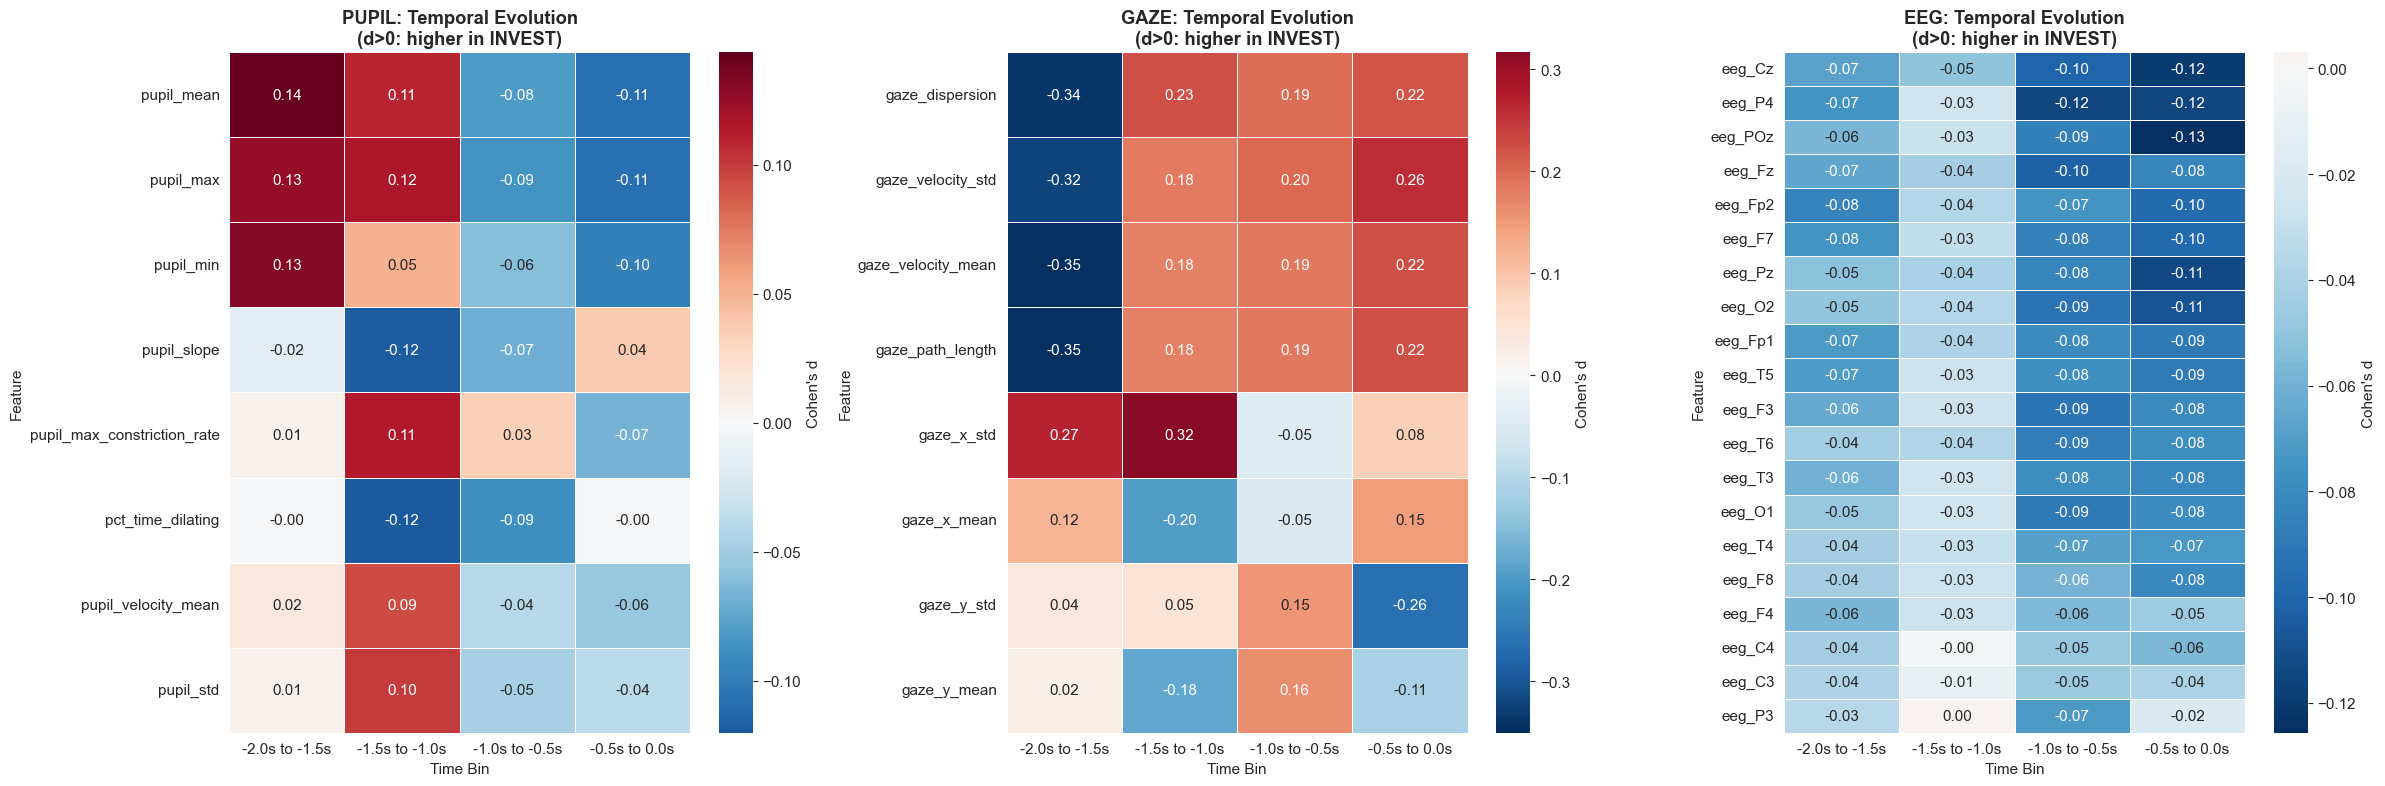

In [10]:
# Heatmaps by modality
n_modalities = temporal_df['modality'].nunique()
fig, axes = plt.subplots(1, n_modalities, figsize=(8*n_modalities, 8))

if n_modalities == 1:
    axes = [axes]

for idx, modality in enumerate(temporal_df['modality'].unique()):
    ax = axes[idx]
    mod_df = temporal_df[temporal_df['modality'] == modality]
    
    pivot = mod_df.pivot(index='feature', columns='bin_idx', values='cohens_d')
    pivot.columns = BIN_LABELS
    
    # Sort by average effect
    pivot['avg'] = pivot.abs().mean(axis=1)
    pivot = pivot.sort_values('avg', ascending=False).drop('avg', axis=1)
    
    sns.heatmap(pivot, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
                cbar_kws={'label': "Cohen's d"}, ax=ax, linewidths=0.5)
    ax.set_xlabel('Time Bin')
    ax.set_ylabel('Feature')
    ax.set_title(f'{modality.upper()}: Temporal Evolution\n(d>0: higher in INVEST)', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'temporal_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

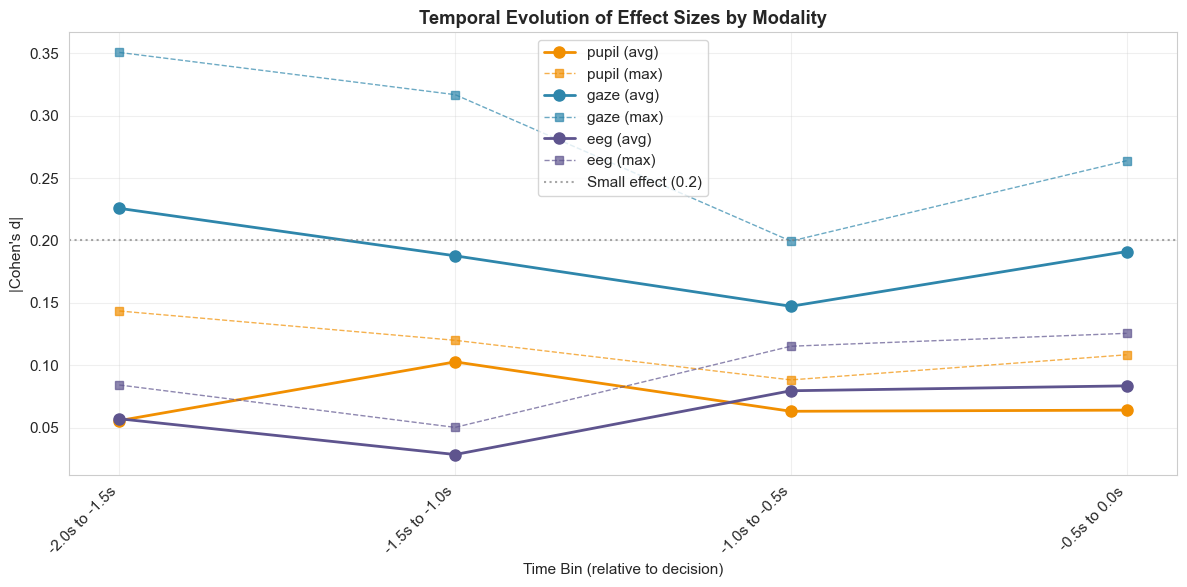

In [11]:
# Cross-modality comparison: effect size over time
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'pupil': '#F18F01', 'gaze': '#2E86AB', 'eeg': '#5E548E'}

for modality in temporal_df['modality'].unique():
    mod_df = temporal_df[temporal_df['modality'] == modality]
    avg_effects = mod_df.groupby('bin_idx')['abs_cohens_d'].mean()
    max_effects = mod_df.groupby('bin_idx')['abs_cohens_d'].max()
    
    x = range(len(TIME_BINS))
    ax.plot(x, avg_effects.values, marker='o', linewidth=2, markersize=8,
            label=f'{modality} (avg)', color=colors.get(modality, 'gray'))
    ax.plot(x, max_effects.values, marker='s', linewidth=1, markersize=6,
            linestyle='--', alpha=0.7, label=f'{modality} (max)', color=colors.get(modality, 'gray'))

ax.axhline(y=0.2, color='gray', linestyle=':', alpha=0.7, label='Small effect (0.2)')
ax.set_xticks(range(len(TIME_BINS)))
ax.set_xticklabels(BIN_LABELS, rotation=45, ha='right')
ax.set_xlabel('Time Bin (relative to decision)')
ax.set_ylabel("|Cohen's d|")
ax.set_title('Temporal Evolution of Effect Sizes by Modality', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'temporal_evolution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Identify Optimal Time Windows

In [12]:
# Find optimal bin for each feature
optimal_bins = []

grouped_max = temporal_df.groupby(['modality', 'feature']).apply(
    lambda x: x.loc[x['abs_cohens_d'].idxmax()],
    include_groups=False
).reset_index()

for _, row in grouped_max.iterrows():
    optimal_bins.append({
        'modality': row['modality'],
        'feature': row['feature'],
        'optimal_bin': row['time_label'],
        'optimal_bin_idx': row['bin_idx'],
        'max_d': row['cohens_d'],
        'abs_max_d': row['abs_cohens_d']
    })

optimal_df = pd.DataFrame(optimal_bins).sort_values('abs_max_d', ascending=False)

print("\n" + "="*80)
print("OPTIMAL TIME BINS BY FEATURE")
print("="*80)
print(optimal_df.to_string(index=False))

# Summary: which bins are most commonly optimal
print("\n" + "="*50)
print("MOST COMMON OPTIMAL BINS")
print("="*50)
bin_counts = optimal_df['optimal_bin'].value_counts()
for bin_label, count in bin_counts.items():
    print(f"  {bin_label}: {count} features ({100*count/len(optimal_df):.1f}%)")


OPTIMAL TIME BINS BY FEATURE
modality                     feature    optimal_bin  optimal_bin_idx     max_d  abs_max_d
    gaze          gaze_velocity_mean -2.0s to -1.5s                0 -0.350540   0.350540
    gaze            gaze_path_length -2.0s to -1.5s                0 -0.350492   0.350492
    gaze             gaze_dispersion -2.0s to -1.5s                0 -0.338023   0.338023
    gaze           gaze_velocity_std -2.0s to -1.5s                0 -0.322694   0.322694
    gaze                  gaze_x_std -1.5s to -1.0s                1  0.316740   0.316740
    gaze                  gaze_y_std  -0.5s to 0.0s                3 -0.263876   0.263876
    gaze                 gaze_x_mean -1.5s to -1.0s                1 -0.195955   0.195955
    gaze                 gaze_y_mean -1.5s to -1.0s                1 -0.183655   0.183655
   pupil                  pupil_mean -2.0s to -1.5s                0  0.143552   0.143552
   pupil                   pupil_min -2.0s to -1.5s                0  

## 9. Test Time-Aligned Feature Extraction

In [13]:
# Create time-aligned features: extract each feature from its optimal bin
print("\nCreating time-aligned features...")

# Map feature -> optimal bin for pupil
optimal_map_pupil = dict(zip(
    optimal_df[optimal_df['modality'] == 'pupil']['feature'],
    optimal_df[optimal_df['modality'] == 'pupil']['optimal_bin_idx'].astype(int)
))

# Extract aligned features
aligned_features = []
for _, row in df.iterrows():
    # Create composite trial_id to match merged_df format
    composite_trial_id = f"{row['trial_id']}_{row['subject_id']}"
    
    aligned_row = {
        'subject_id': row['subject_id'],
        'trial_id': composite_trial_id,
        'outcome': row['outcome']
    }
    
    for feature, opt_bin in optimal_map_pupil.items():
        col_name = f'{feature}_bin{opt_bin}'
        if col_name in row:
            aligned_row[f'{feature}_aligned'] = row[col_name]
    
    aligned_features.append(aligned_row)

aligned_df = pd.DataFrame(aligned_features)
aligned_cols = [c for c in aligned_df.columns if c.endswith('_aligned')]
print(f"Created {len(aligned_cols)} aligned pupil features")
print(f"Sample trial_id format: {aligned_df['trial_id'].iloc[0]}")


Creating time-aligned features...
Created 8 aligned pupil features
Sample trial_id format: 4_0731_1000_539136F


In [14]:
# Merge with behavior and gaze for fusion comparison
aligned_merged = aligned_df.merge(
    merged_df[['trial_id'] + behavior_cols + gaze_cols],
    on='trial_id',
    how='inner'
)

print(f"Merged dataset: {len(aligned_merged)} trials")

# Prepare data for fusion
X_aligned = SimpleImputer(strategy='mean').fit_transform(aligned_merged[aligned_cols])
X_behavior = SimpleImputer(strategy='mean').fit_transform(aligned_merged[behavior_cols])
X_gaze = SimpleImputer(strategy='mean').fit_transform(aligned_merged[gaze_cols])
y = aligned_merged['outcome'].values
subjects = aligned_merged['subject_id'].values

print(f"\nFeature shapes:")
print(f"  Physio (aligned): {X_aligned.shape}")
print(f"  Behavior: {X_behavior.shape}")
print(f"  Gaze: {X_gaze.shape}")

Merged dataset: 10048 trials

Feature shapes:
  Physio (aligned): (10048, 8)
  Behavior: (10048, 11)
  Gaze: (10048, 20)


In [15]:
# Run time-aligned fusion
print("\nRunning time-aligned late fusion...")
X_modalities_aligned = [X_aligned, X_behavior, X_gaze]
modality_names = ['Physio (Aligned)', 'Behavior', 'Gaze']

results_aligned = weighted_late_fusion(
    X_modalities_aligned, y, subjects, modality_names, fusion_method='weighted'
)

print(f"\nTIME-ALIGNED RESULTS:")
print(f"  Accuracy: {results_aligned['accuracy_mean']:.4f} ± {results_aligned['accuracy_sem']:.4f}")
print(f"  Weights: {dict(zip(modality_names, [f'{w:.3f}' for w in results_aligned['weights']]))}")


Running time-aligned late fusion...


/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w


TIME-ALIGNED RESULTS:
  Accuracy: 0.7399 ± 0.0132
  Weights: {'Physio (Aligned)': '0.008', 'Behavior': '0.686', 'Gaze': '0.306'}


In [16]:
# Run baseline (full window) for comparison
baseline_merged = merged_df[merged_df['trial_id'].isin(aligned_merged['trial_id'])]

X_physio_baseline = SimpleImputer(strategy='mean').fit_transform(baseline_merged[physio_cols])
X_behavior_baseline = SimpleImputer(strategy='mean').fit_transform(baseline_merged[behavior_cols])
X_gaze_baseline = SimpleImputer(strategy='mean').fit_transform(baseline_merged[gaze_cols])
y_baseline = baseline_merged['outcome'].values
subjects_baseline = baseline_merged['subject_id'].values

print("\nRunning baseline (full window) late fusion...")
X_modalities_baseline = [X_physio_baseline, X_behavior_baseline, X_gaze_baseline]
modality_names_baseline = ['Physio (Full)', 'Behavior', 'Gaze']

results_baseline = weighted_late_fusion(
    X_modalities_baseline, y_baseline, subjects_baseline, modality_names_baseline, fusion_method='weighted'
)

print(f"\nBASELINE (FULL WINDOW) RESULTS:")
print(f"  Accuracy: {results_baseline['accuracy_mean']:.4f} ± {results_baseline['accuracy_sem']:.4f}")
print(f"  Weights: {dict(zip(modality_names_baseline, [f'{w:.3f}' for w in results_baseline['weights']]))}")


Running baseline (full window) late fusion...

BASELINE (FULL WINDOW) RESULTS:
  Accuracy: 0.7408 ± 0.0134
  Weights: {'Physio (Full)': '0.010', 'Behavior': '0.684', 'Gaze': '0.305'}


In [17]:
# Compare results
print("\n" + "="*70)
print("COMPARISON: TIME-ALIGNED vs FULL WINDOW")
print("="*70)

acc_diff = results_aligned['accuracy_mean'] - results_baseline['accuracy_mean']

comparison = pd.DataFrame([
    {'Method': 'Full Window', 'Accuracy': results_baseline['accuracy_mean'], 'SEM': results_baseline['accuracy_sem']},
    {'Method': 'Time-Aligned', 'Accuracy': results_aligned['accuracy_mean'], 'SEM': results_aligned['accuracy_sem']}
])
print(comparison.to_string(index=False))

print(f"\nAccuracy difference: {acc_diff:+.4f} ({100*acc_diff/results_baseline['accuracy_mean']:+.2f}%)")

if abs(acc_diff) < 0.005:
    print("\nConclusion: Time-aligned extraction shows MINIMAL impact.")
    print("Full window aggregation already captures the relevant signals.")
elif acc_diff > 0:
    print(f"\nConclusion: Time-aligned extraction shows IMPROVEMENT.")
else:
    print(f"\nConclusion: Time-aligned extraction shows DECREASE.")


COMPARISON: TIME-ALIGNED vs FULL WINDOW
      Method  Accuracy      SEM
 Full Window  0.740843 0.013397
Time-Aligned  0.739855 0.013154

Accuracy difference: -0.0010 (-0.13%)

Conclusion: Time-aligned extraction shows MINIMAL impact.
Full window aggregation already captures the relevant signals.


## 10. Save Results

In [18]:
# Save all results
temporal_df.to_csv(OUTPUT_DIR / 'temporal_divergence_all.csv', index=False)
optimal_df.to_csv(OUTPUT_DIR / 'optimal_time_bins.csv', index=False)
comparison.to_csv(OUTPUT_DIR / 'alignment_comparison.csv', index=False)

print("\n" + "="*70)
print("FILES SAVED")
print("="*70)
print(f"  - {OUTPUT_DIR / 'temporal_divergence_all.csv'}")
print(f"  - {OUTPUT_DIR / 'optimal_time_bins.csv'}")
print(f"  - {OUTPUT_DIR / 'alignment_comparison.csv'}")
print(f"  - {OUTPUT_DIR / 'temporal_heatmaps.png'}")
print(f"  - {OUTPUT_DIR / 'temporal_evolution_comparison.png'}")


FILES SAVED
  - ../../data/results/main/statistical_analyses/temporal_dynamics/temporal_divergence_all.csv
  - ../../data/results/main/statistical_analyses/temporal_dynamics/optimal_time_bins.csv
  - ../../data/results/main/statistical_analyses/temporal_dynamics/alignment_comparison.csv
  - ../../data/results/main/statistical_analyses/temporal_dynamics/temporal_heatmaps.png
  - ../../data/results/main/statistical_analyses/temporal_dynamics/temporal_evolution_comparison.png


## 11. Key Findings

In [19]:
print("\n" + "="*70)
print("KEY FINDINGS: TEMPORAL DYNAMICS")
print("="*70)

# Signal emergence
print("\n1. SIGNAL EMERGENCE:")
for modality in temporal_df['modality'].unique():
    mod_df = temporal_df[temporal_df['modality'] == modality]
    strongest = mod_df.loc[mod_df['abs_cohens_d'].idxmax()]
    print(f"   {modality.upper()}: Strongest at {strongest['time_label']} ({strongest['feature']}, d={strongest['cohens_d']:.3f})")

# Optimal windows
print("\n2. OPTIMAL TIME WINDOWS:")
for bin_label, count in bin_counts.head(3).items():
    print(f"   {bin_label}: {count} features")

# Alignment impact
print("\n3. TIME-ALIGNED EXTRACTION IMPACT:")
print(f"   Baseline accuracy: {results_baseline['accuracy_mean']:.4f}")
print(f"   Aligned accuracy: {results_aligned['accuracy_mean']:.4f}")
print(f"   Difference: {acc_diff:+.4f}")

print(f"\n" + "="*70)
print(f"Analysis completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)


KEY FINDINGS: TEMPORAL DYNAMICS

1. SIGNAL EMERGENCE:
   PUPIL: Strongest at -2.0s to -1.5s (pupil_mean, d=0.144)
   GAZE: Strongest at -2.0s to -1.5s (gaze_velocity_mean, d=-0.351)
   EEG: Strongest at -0.5s to 0.0s (eeg_POz, d=-0.126)

2. OPTIMAL TIME WINDOWS:
   -0.5s to 0.0s: 13 features
   -2.0s to -1.5s: 8 features
   -1.5s to -1.0s: 8 features

3. TIME-ALIGNED EXTRACTION IMPACT:
   Baseline accuracy: 0.7408
   Aligned accuracy: 0.7399
   Difference: -0.0010

Analysis completed: 2026-03-30 16:58:47
